# XGBoost — Prediksi Status Akademik Mahasiswa

Notebook ini menggunakan model **XGBoost Classifier** untuk memprediksi `Status Akademik` mahasiswa menggunakan Dataset Kehadiran, Aktivitas, dan IPK.

## 1. Import Library

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Load Dataset

In [11]:
# Membaca dataset excel
df = pd.read_excel('Dataset_Mahasiswa_Kehadiran_Aktivitas_IPK.xlsx')
print('Dataset berhasil dimuat!')
df.head()

Dataset berhasil dimuat!


,Nama,Jenis Kelamin,Umur,Status Menikah,Kehadiran (%),Partisipasi Diskusi (skor),Nilai Tugas (rata-rata),Aktivitas E-Learning (skor),IPK,Status Akademik
0,Kiki Ananda,Laki-laki,20,Belum Menikah,73,99,91,88,3.77,Lulus
1,Putri Fauzi,Laki-laki,21,Belum Menikah,42,83,53,64,3.55,Lulus
2,Mira Hidayat,Laki-laki,25,Belum Menikah,71,61,87,54,2.73,Lulus
3,Mira Ananda,Laki-laki,23,Belum Menikah,44,88,62,81,3.59,Tidak
4,Mira Septiani,Laki-laki,21,Menikah,54,92,67,64,3.02,Lulus


## 3. Eksplorasi Data (EDA)

In [12]:
print('Jumlah baris dan kolom:', df.shape)
print('\nInfo Dataset:')
df.info()

Jumlah baris dan kolom: (500, 10)

Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nama                         500 non-null    str    
 1   Jenis Kelamin                500 non-null    str    
 2   Umur                         500 non-null    int64  
 3   Status Menikah               500 non-null    str    
 4   Kehadiran (%)                500 non-null    int64  
 5   Partisipasi Diskusi (skor)   500 non-null    int64  
 6   Nilai Tugas (rata-rata)      500 non-null    int64  
 7   Aktivitas E-Learning (skor)  500 non-null    int64  
 8   IPK                          500 non-null    float64
 9   Status Akademik              500 non-null    str    
dtypes: float64(1), int64(5), str(4)
memory usage: 39.2 KB


Distribusi Status Akademik:
Status Akademik
Lulus    270
Tidak    230
Name: count, dtype: int64


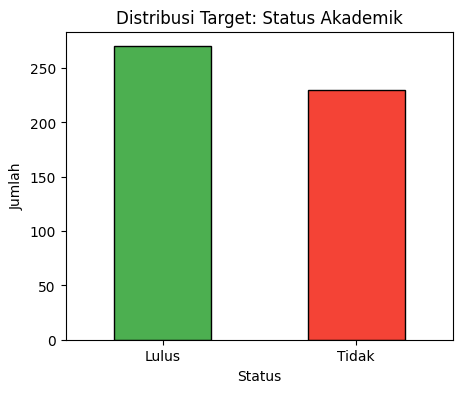

In [13]:
print('Distribusi Status Akademik:')
print(df['Status Akademik'].value_counts())

plt.figure(figsize=(5, 4))
df['Status Akademik'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'], edgecolor='black')
plt.title('Distribusi Target: Status Akademik')
plt.xlabel('Status')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

## 4. Preprocessing Data

In [14]:
# Memilih fitur yang relevan saja sesuai permintaan
fitur = ['Kehadiran (%)', 'Partisipasi Diskusi (skor)', 'Nilai Tugas (rata-rata)', 'Aktivitas E-Learning (skor)', 'IPK']
df_model = df[fitur + ['Status Akademik']].copy()

# Encoding data kategorikal (Hanya Target: Status Akademik)
le_target = LabelEncoder()
df_model['Status Akademik'] = le_target.fit_transform(df_model['Status Akademik'])

print("Mapping Status Akademik:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
df_model.head()

Mapping Status Akademik: {'Lulus': np.int64(0), 'Tidak': np.int64(1)}


,Kehadiran (%),Partisipasi Diskusi (skor),Nilai Tugas (rata-rata),Aktivitas E-Learning (skor),IPK,Status Akademik
0,73,99,91,88,3.77,0
1,42,83,53,64,3.55,0
2,71,61,87,54,2.73,0
3,44,88,62,81,3.59,1
4,54,92,67,64,3.02,0


## 5. Splitting Data (Train & Test)

In [15]:
X = df_model.drop(columns=['Status Akademik'])
y = df_model['Status Akademik']

# Pisahkan menjadi set pelatihan (80%) dan pengujian (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Dimensi data training:', X_train.shape)
print('Dimensi data testing:', X_test.shape)

Dimensi data training: (400, 5)
Dimensi data testing: (100, 5)


## 6. Modelling: XGBoost Classifier

In [16]:
# Buat instance model XGBoost
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
print('Model XGBoost berhasil ditraining!')

Model XGBoost berhasil ditraining!


## 7. Evaluasi Model

Akurasi Model: 66.00%

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.74      0.70        54
           1       0.65      0.57      0.60        46

    accuracy                           0.66       100
   macro avg       0.66      0.65      0.65       100
weighted avg       0.66      0.66      0.66       100



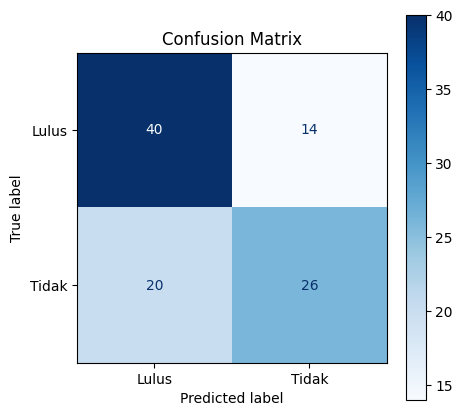

In [17]:
y_pred = xgb_model.predict(X_test)

# Hitung akurasi
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {acc * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Tampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## 8. Visualisasi Feature Importance

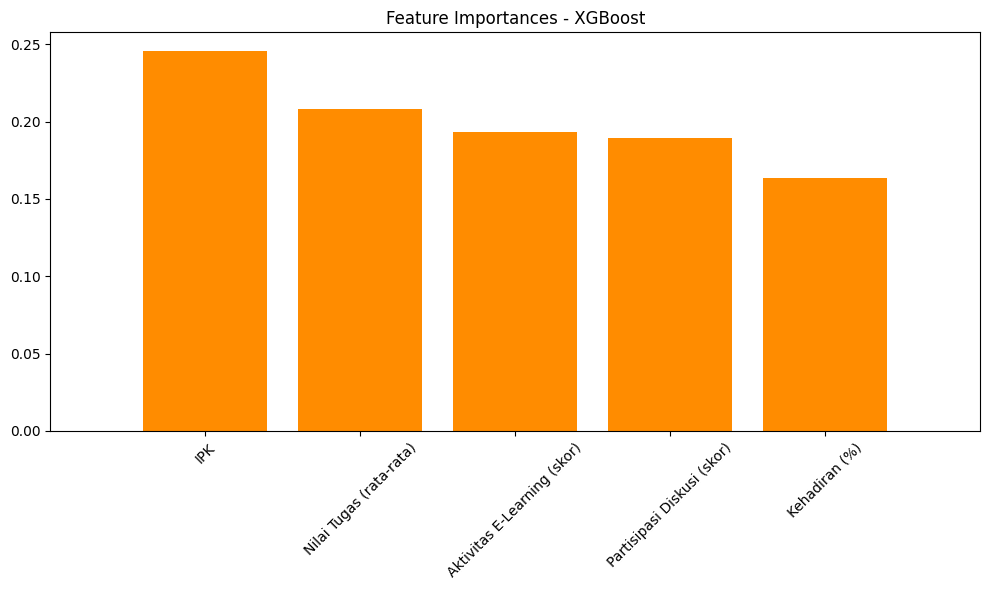

In [18]:
# Mendapatkan nilai importance fitur dari model XGBoost
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 6))
plt.title('Feature Importances - XGBoost')
plt.bar(range(X.shape[1]), importances[indices], color='darkorange', align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

## 9. Prediksi Status Pada Data Baru

In [19]:
# Simulasi dataframe untuk 2 mahasiswa baru dengan fitur yang kita gunakan
data_baru = pd.DataFrame({
    'Kehadiran (%)': [95.0, 50.0],
    'Partisipasi Diskusi (skor)': [85.0, 40.0],
    'Nilai Tugas (rata-rata)': [88.5, 60.0],
    'Aktivitas E-Learning (skor)': [92.0, 45.0],
    'IPK': [3.80, 2.10]
})

print("Data Mahasiswa Baru:")
display(data_baru)

# Melakukan prediksi menggunakan model XGBoost
prediksi = xgb_model.predict(data_baru)

# Mengubah hasil prediksi numerik menjadi label (Lulus / Tidak Lulus)
prediksi_label = le_target.inverse_transform(prediksi)
data_baru['Prediksi Status Akademik'] = prediksi_label

print("\nHasil Prediksi Akhir:")
display(data_baru)

Data Mahasiswa Baru:


,Kehadiran (%),Partisipasi Diskusi (skor),Nilai Tugas (rata-rata),Aktivitas E-Learning (skor),IPK
0,95.0,85.0,88.5,92.0,3.8
1,50.0,40.0,60.0,45.0,2.1



Hasil Prediksi Akhir:


,Kehadiran (%),Partisipasi Diskusi (skor),Nilai Tugas (rata-rata),Aktivitas E-Learning (skor),IPK,Prediksi Status Akademik
0,95.0,85.0,88.5,92.0,3.8,Lulus
1,50.0,40.0,60.0,45.0,2.1,Lulus
